## BINARY CLASSIFICATION

### DATA GENERATION

In [96]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [131]:
# Training data generation and dataset composition
N = 200
x1 = np.random.normal(0, 1, (N, 2))
y1 = np.zeros((N,1), dtype=int)
x2 = np.random.normal(1.5, 0.8, (N, 2))
y2 = np.ones((N,1), dtype=int)
Y = np.vstack([y1, y2])
X = np.vstack([x1, x2])

# Validation data
N = 50
x1 = np.random.normal(0, 1, (N, 2))
y1 = np.zeros((N,1), dtype=int)
x2 = np.random.normal(1.5, 0.8, (N, 2))
y2 = np.ones((N,1), dtype=int)
Y_val = np.vstack([y1, y2])
X_val = np.vstack([x1, x2])

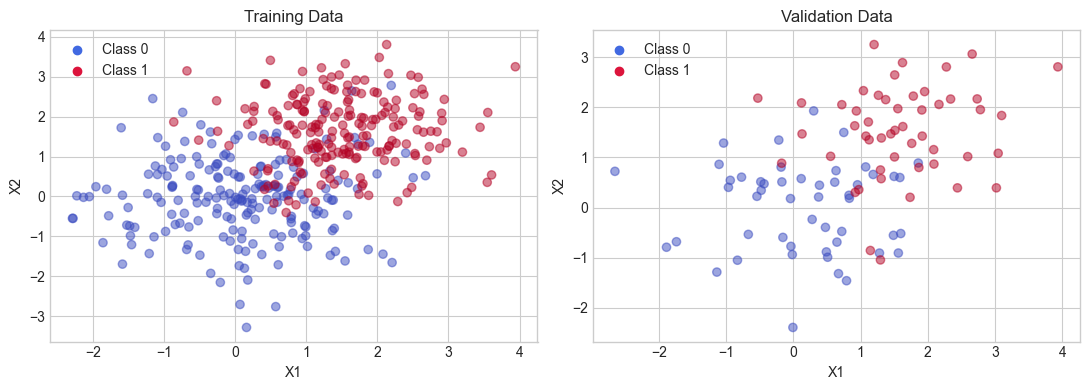

In [132]:
# Data visualization
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(X[:,0], X[:,1], c = Y.ravel(), cmap='coolwarm', alpha = 0.5)
ax[0].set_title('Training Data')
ax[0].set_xlabel('X1')
ax[0].set_ylabel('X2')
ax[0].scatter([], [], color='royalblue', label='Class 0')
ax[0].scatter([], [], color='crimson', label='Class 1')
ax[0].legend()

ax[1].scatter(X_val[:,0], X_val[:,1], c = Y_val.ravel(), cmap='coolwarm', alpha = 0.5)
ax[1].set_title('Validation Data')
ax[1].set_xlabel('X1')
ax[1].set_ylabel('X2')
ax[1].scatter([], [], color='royalblue', label='Class 0')
ax[1].scatter([], [], color='crimson', label='Class 1')
ax[1].legend()

plt.tight_layout()
plt.show()

### MODEL ARCHITECTURE

In [ ]:
# input -> weights + bias -> layer -> ReLU -> weights + bias -> sigmoid (>= 0.5 -> 1) -> Loss

In [133]:
N = X.shape[0]
neurons = 5
# Initialization weights first and second layer (Kaiming initialization)
W1_start = np.random.normal(0, 6/N, (neurons, X.shape[1])) # General dimensions rule: output x input
b1_start = np.ones((neurons,1))
W2_start = np.random.normal(0, 6/N, (1, neurons))
b2_start = np.zeros((1,1))

In [100]:
def ReLU(x):
    n = x.shape[0]
    p = x.shape[1]
    for i in range(n):
        for j in range(p):
            if x[i, j] > 0:
                continue
            else:
                x[i, j] = 0
    return x

In [101]:
def tanh(x):
    return (1 - np.exp(-2*x))/(1 + np.exp(-2*x))

In [102]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

In [103]:
def cross_entropy(x, y): # Only with sigmoid input
    return -np.sum(y * np.log(x) + (1 - y) * np.log(1 - x))

### FORWARD PASS

In [104]:
def forward_pass(X, W1, b1, W2, b2):
    # First layer
    h1 = X @ W1.T + b1.T # Pre-activation
    a1 = ReLU(h1) # Can also be chosen sigmoid() or tanh() as activation functions
    # Clearly if it's chosen to change some of the functions the same must be applied to the backpropagation function
    # Second layer
    h2 = a1 @ W2.T + b2.T
    # Final prediction (probability)
    y_hat = sigmoid(h2)
    return h1, a1, h2, y_hat

### BACKPROPAGATION

In [105]:
def backpropagation(X, Y, y_hat, h2, a1, h1, W1, W2, b1, b2, B):
    dLdy = -(Y / y_hat) + (1 - Y)/(1 - y_hat)
    dydh2 = sigmoid(h2)*(1 - sigmoid(h2))
    d2 = dLdy * dydh2
    dW2 = d2.T @ a1
    db2 = np.sum(d2, axis=0, keepdims=True)

    da1dh1 = (h1 > 0).astype(float) # Derivative of ReLU: ReLU'(x) = {1 if x>0, 0 otherwise}
    d1 = (d2 @ W2) * da1dh1
    dW1 = d1.T @ X
    db1 = np.sum(d1, axis=0, keepdims=True)

    dW1 /= B # Divide by the minibatch size to scale the gradients
    dW2 /= B
    db1 /= B
    db2 /= B
    return dW1, dW2, db1, db2

### TRAINING

In [106]:
def early_stop(validation_loss, best_val = float("inf"), wait = 0, patience = 3, min_delta = 1e-3):
    stop = 0
    if validation_loss < best_val - min_delta:
          best_val = validation_loss
          wait = 0
    else:
          wait += 1
    if wait >= patience:
        stop = 1
    return stop, best_val, wait

In [107]:
def training(X, Y, W1, W2, b1, b2, minibatch = 10, epochs = 5, lr = 1e-2, pat = 3, tol = 1e-3):
    history_train_loss = []
    history_val_loss = []
    history_train_acc = []
    history_val_acc = []
    W1_grad = 0
    b1_grad = 0
    W2_grad = 0
    b2_grad = 0
    for e in range(epochs):
        # Random sampling of the examples
        ind = np.arange(X.shape[0])
        np.random.shuffle(ind)
        j = 0
        for i in range(minibatch, N + minibatch, minibatch):
            # Permutation of the sampled examples
            b = ind[j:i]
            # Forward pass
            h1, a1, h2, y_tr_hat = forward_pass(X[b,], W1, b1, W2, b2)
            # Loss
            loss_train = cross_entropy(y_tr_hat, Y[b])
            # Backpropagation
            dW1, dW2, db1, db2 = backpropagation(X[b,], Y[b], y_tr_hat, h2, a1, h1, W1, W2, b1, b2, B = minibatch)
            # Weights update
            W1 -= lr * dW1
            b1 -= lr * db1.T
            W2 -= lr * dW2
            b2 -= lr * db2.T

            j = i

        history_train_loss.append(loss_train)
        y_tr_hat = np.round(y_tr_hat)
        # Prediction threshold fixed at y_hat (probability) >= 0.5 -> y_hat = 1, otherwise y_hat = 0
        history_train_acc.append(accuracy_score(Y[b], np.round(y_tr_hat)))

        _, _, _, y_val_hat = forward_pass(X_val, W1, b1, W2, b2)
        loss_val = cross_entropy(y_val_hat, Y_val)
        history_val_loss.append(loss_val)
        y_val_hat = np.round(y_val_hat)
        history_val_acc.append(accuracy_score(Y_val, y_val_hat))

        # Early stopping
        if e == 0:
            e_stop, e_b_val, e_wait = early_stop(loss_val, patience = pat, min_delta = tol)
        else:
            e_stop, e_b_val, e_wait = early_stop(loss_val, e_b_val, e_wait, patience = pat, min_delta = tol)
        if e_stop:
            print("#----------STOPED BY: Early stopping----------#")
            print(f'Final Epoch: {e+1}')
            print(f'Final Training Loss : {round(history_train_loss[-1], 5)}')
            print(f'Final Validation Loss : {round(history_val_loss[-1], 5)}')
            print(f'Final Validation Accuracy : {round(history_val_acc[-1], 5)}')
            break 

        if e % 2 == 0:
          print(f'Epoch: {e+1}')
          print(f'Training Loss {round(history_train_loss[-1], 5)}')
          print(f'Validation Loss {round(history_val_loss[-1], 5)}')

    return history_train_loss, history_val_loss, history_val_acc, history_train_acc, W1, b1, W2, b2

In [134]:
tr_loss, val_loss, acc_val, acc_tr, final_W1, final_b1, final_W2, final_b2 = training(X, Y, W1_start, W2_start, b1_start, b2_start, 
                                                                                      minibatch = 20, epochs = 30, lr = 0.3, pat=5, 
                                                                                      tol = 1e-3)

Epoch: 1
Training Loss 13.16176
Validation Loss 65.53224
Epoch: 3
Training Loss 2.88421
Validation Loss 30.13068
Epoch: 5
Training Loss 8.5455
Validation Loss 30.25056
Epoch: 7
Training Loss 9.31002
Validation Loss 31.45019
#----------STOPED BY: Early stopping----------#
Final Epoch: 8
Final Training Loss : 5.00068
Final Validation Loss : 30.89545
Final Validation Accuracy : 0.88


### VISUALIZATION OF THE MODEL SELECTION

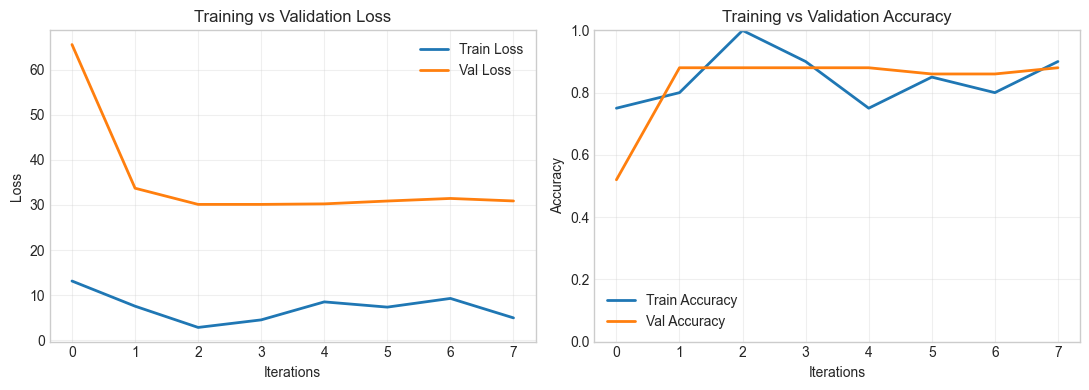

In [135]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# -------- LOSS --------
ax[0].plot(tr_loss, label='Train Loss', linewidth=2)
ax[0].plot(val_loss, label='Val Loss', linewidth=2)
ax[0].set_title('Training vs Validation Loss')
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# -------- ACCURACY --------
ax[1].plot(acc_tr, label='Train Accuracy', linewidth=2)
ax[1].plot(acc_val, label='Val Accuracy', linewidth=2)
ax[1].set_title('Training vs Validation Accuracy')
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim(0, 1)
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### VISUALIZATION OF THE THRESHOLD

In [136]:
def prediction_grid(x1, x2, final_W1, final_b1, final_W2, final_b2):
    y_grid = np.zeros((len(x2), len(x1)))
    for i in range(len(x1)):
        for j in range(len(x2)):
            _, _, _, y_grid[j, i] = forward_pass(np.array([[x1[i], x2[j]]]), final_W1, final_b1, final_W2, final_b2)
            
    return y_grid
x1 = np.arange(np.min(X_val[:,0])-0.5, np.max(X_val[:,0])+0.5, 0.02)
x2 = np.arange(np.min(X_val[:,1])-0.5, np.max(X_val[:,1])+0.5, 0.02) 
y_grid = prediction_grid(x1, x2, final_W1, final_b1, final_W2, final_b2)

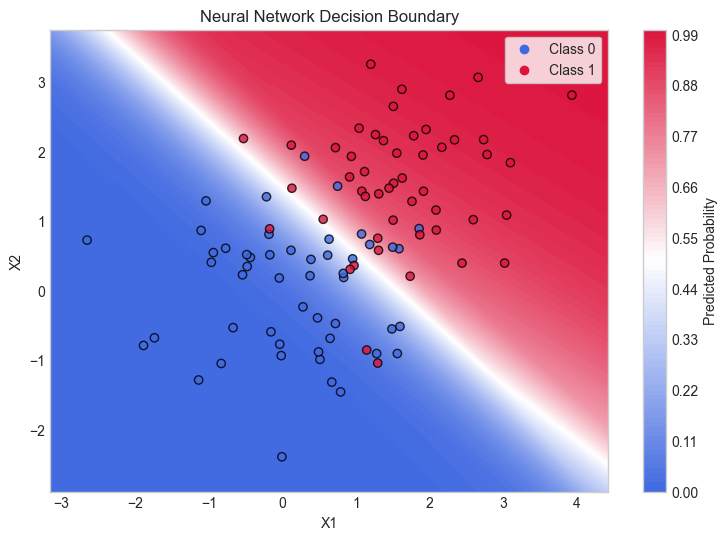

In [137]:
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    'custom_boundary',
    [
        (0.0, 'royalblue'), # For probabilities near 0 -> more confidence for classificatio of y = 0
        (0.5, 'white'),     # For probabilities near 0.5 -> no confidence for either one of the two classes (model threshold)
        (1.0, 'crimson')    # For probabilities near 1 -> more confidence for classificatio of y = 1
    ]
)

plt.figure(figsize=(9,6))

contour = plt.contourf(x1, x2, y_grid, levels=100, cmap=custom_cmap)

# validation points
plt.scatter(X_val[:,0], X_val[:,1], c=Y_val.ravel(), cmap=custom_cmap, edgecolors='black', alpha=0.8)

plt.scatter([], [], color='royalblue', label='Class 0')
plt.scatter([], [], color='crimson', label='Class 1')
plt.legend(frameon = True)

cbar = plt.colorbar(contour)
cbar.set_label('Predicted Probability')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Neural Network Decision Boundary')

plt.show()

## MULTICLASS CLASSIFICATION

### DATA GENERATION

In [138]:
from sklearn.metrics import f1_score
# Training data generation and dataset composition
# N = 100, but this time classes are also unbalanced
x1 = np.random.normal(0, 1, (60, 2))
y1 = np.zeros((60,1), dtype=int)
x2 = np.random.normal(1.5, 0.8, (30, 2))
y2 = np.ones((30,1), dtype=int)
x3 = np.random.normal((-1, 2.5), 0.3, (20, 2))
y3 = np.full((20,1), 2, dtype=int)
x4 = np.random.normal((2, -1), 0.5, (40, 2))
y4 = np.full((40,1), 3, dtype=int)

Y = np.vstack([y1, y2, y3, y4])
X = np.vstack([x1, x2, x3, x4])

# Validation data
# N = 60
x1 = np.random.normal(0, 1, (15, 2))
y1 = np.zeros((15,1), dtype=int)
x2 = np.random.normal(1.5, 0.8, (15, 2))
y2 = np.ones((15,1), dtype=int)
x3 = np.random.normal((-1, 2.5), 0.3, (15, 2))
y3 = np.full((15,1), 2, dtype=int)
x4 = np.random.normal((2, -1), 0.5, (15, 2))
y4 = np.full((15,1), 3, dtype=int)

Y_val = np.vstack([y1, y2, y3, y4])
X_val = np.vstack([x1, x2, x3, x4])

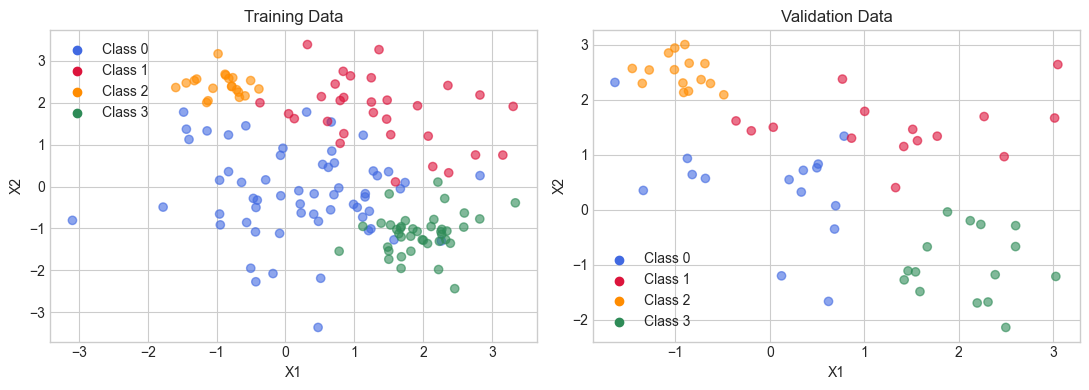

In [139]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

cmap = ListedColormap([
    'royalblue',
    'crimson',
    'darkorange',
    'seagreen'
])

ax[0].scatter(X[:,0],X[:,1],c=Y.ravel(),cmap=cmap,alpha=0.6)
ax[0].set_title('Training Data')
ax[0].set_xlabel('X1')
ax[0].set_ylabel('X2')
ax[0].scatter([], [], color='royalblue', label='Class 0')
ax[0].scatter([], [], color='crimson', label='Class 1')
ax[0].scatter([], [], color='darkorange', label='Class 2')
ax[0].scatter([], [], color='seagreen', label='Class 3')
ax[0].legend()

ax[1].scatter(X_val[:,0],X_val[:,1],c=Y_val.ravel(),cmap=cmap,alpha=0.6)
ax[1].set_title('Validation Data')
ax[1].set_xlabel('X1')
ax[1].set_ylabel('X2')
ax[1].scatter([], [], color='royalblue', label='Class 0')
ax[1].scatter([], [], color='crimson', label='Class 1')
ax[1].scatter([], [], color='darkorange', label='Class 2')
ax[1].scatter([], [], color='seagreen', label='Class 3')
ax[1].legend()

plt.tight_layout()
plt.show()

### FORWARD PASS

In [140]:
N = X.shape[0]
neurons = 15
# Initialization weights first and second layer (Kaiming initialization)
W1_start = np.random.normal(0, 6/N, (neurons, X.shape[1])) # General dimensions rule: output x input
b1_start = np.ones((neurons,1))
W2_start = np.random.normal(0, 6/N, (4, neurons)) # 4 is the number of classes
b2_start = np.zeros((4,1))

In [8]:
def softmax(x): # x: (minibatch, #classes)
    tot = 0
    prob = np.zeros((x.shape[0], x.shape[1]))
    for i in range(x.shape[0]):
        tot = np.sum(np.exp(x[i,]))
        prob[i,] = np.exp(x[i,]) / tot
    return prob

In [9]:
def forward_pass(X, W1, b1, W2, b2):
    # First layer
    h1 = X @ W1.T + b1.T # Pre-activation
    a1 = ReLU(h1) # Can also be chosen sigmoid() or tanh() as activation functions
    # Second layer
    h2 = a1 @ W2.T + b2.T
    # Final prediction (probability)
    y_hat = softmax(h2)
    #y_hat = np.argmax(y_hat, axis = 1) # Takes the index corresponding to the highest value
    return h1, a1, h2, y_hat

In [10]:
def one_hot_encoding(x):
    x_ohe = np.zeros((x.shape[0], 4))
    for i in range(len(x)):
        if x[i] == 0:
            x_ohe[i,] = np.array([1,0,0,0])
        elif x[i] == 1:
            x_ohe[i,] = np.array([0,1,0,0])
        elif x[i] == 2:
            x_ohe[i,] = np.array([0,0,1,0])
        elif x[i] == 3:
            x_ohe[i,] = np.array([0,0,0,1])

    return x_ohe

In [11]:
def categorical_cross_entropy(x, y): # Only with sigmoid input
    B = x.shape[0]
    L = 0
    for i in range(B):
        L += np.sum(y[i,] * np.log(x[i,]))
    return -L/B

### BACKPROPAGATION

In [12]:
def backpropagation(X, Y, y_hat, h2, a1, h1, W1, W2, b1, b2, B):
    d2 = y_hat - Y # By simplification of the softmax + cross entropy loss
    dW2 = d2.T @ a1
    db2 = np.sum(d2, axis=0, keepdims=True)

    da1dh1 = (h1 > 0).astype(float) # Derivative of ReLU: ReLU'(x) = {1 if x>0, 0 otherwise}
    d1 = (d2 @ W2) * da1dh1
    dW1 = d1.T @ X
    db1 = np.sum(d1, axis=0, keepdims=True)

    dW1 /= B # Divide by the minibatch size to scale the gradients
    dW2 /= B
    db1 /= B
    db2 /= B
    return dW1, dW2, db1, db2

In [141]:
def training(X, Y, Y_val, W1, W2, b1, b2, minibatch = 10, epochs = 5, lr = 1e-2, pat = 3, tol = 1e-3):
    N = X.shape[0]
    Y_ohe = one_hot_encoding(Y)
    Y_val_ohe = one_hot_encoding(Y_val)
    history_train_loss = []
    history_val_loss = []
    history_train_acc = []
    history_val_acc = []
    history_train_f1 = []
    history_val_f1 = []
    W1_grad = 0
    b1_grad = 0
    W2_grad = 0
    b2_grad = 0
    for e in range(epochs):
        # Random sampling of the examples
        ind = np.arange(N)
        np.random.shuffle(ind)
        j = 0
        for i in range(minibatch, N + minibatch, minibatch):
            # Permutation of the sampled examples
            b = ind[j:i]
            # Forward pass
            h1, a1, h2, y_tr_hat = forward_pass(X[b,], W1, b1, W2, b2)
            # Loss
            loss_train = categorical_cross_entropy(y_tr_hat, Y_ohe[b,])
            # Backpropagation
            dW1, dW2, db1, db2 = backpropagation(X[b,], Y_ohe[b,], y_tr_hat, h2, a1, h1, W1, W2, b1, b2, B = minibatch)

            W1 -= lr * dW1
            b1 -= lr * db1.T
            W2 -= lr * dW2
            b2 -= lr * db2.T

            j = i

        history_train_loss.append(loss_train)
        y_tr_hat = np.argmax(y_tr_hat, axis = 1)
        history_train_acc.append(accuracy_score(Y[b,], y_tr_hat))
        history_train_f1.append(f1_score(Y[b,], y_tr_hat, average = 'macro'))

        _, _, _, y_val_hat = forward_pass(X_val, W1, b1, W2, b2)
        loss_val = categorical_cross_entropy(y_val_hat, Y_val_ohe)
        history_val_loss.append(loss_val)
        y_val_hat = np.argmax(y_val_hat, axis = 1)
        history_val_acc.append(accuracy_score(Y_val, y_val_hat))
        history_val_f1.append(f1_score(Y_val, y_val_hat, average = 'macro'))

        # Early stopping
        if e == 0:
            e_stop, e_b_val, e_wait = early_stop(loss_val, patience = pat, min_delta = tol)
        else:
            e_stop, e_b_val, e_wait = early_stop(loss_val, e_b_val, e_wait, patience = pat, min_delta = tol)
        if e_stop:
            print("#----------STOPED BY: Early stopping----------#")
            print(f'Final Epoch: {e+1}')
            print(f'Final Training Loss : {round(history_train_loss[-1], 5)}')
            print(f'Final Validation Loss : {round(history_val_loss[-1], 5)}')
            print(f'Final Validation Accuracy : {round(history_val_acc[-1], 5)}')
            print(f'Final Validation F1-score : {round(history_val_f1[-1], 5)}')
            break 

        if e % 2 == 0:
          print(f'Epoch: {e+1}')
          print(f'Training Loss {round(history_train_loss[-1], 5)}')
          print(f'Validation Loss {round(history_val_loss[-1], 5)}')

    return history_train_loss, history_val_loss, history_train_acc, history_val_acc, history_train_f1, history_val_f1, W1, b1, W2, b2

In [142]:
tr_loss, val_loss, acc_tr, acc_val, f1_tr, f1_val, final_W1, final_b1, final_W2, final_b2 = training(X, Y, Y_val, W1_start, W2_start, 
                                                  b1_start, b2_start, minibatch = 10, 
                                                  epochs = 60, lr = 0.1, pat=5, tol = 1e-3)

Epoch: 1
Training Loss 1.13262
Validation Loss 1.36706
Epoch: 3
Training Loss 0.86127
Validation Loss 0.97158
Epoch: 5
Training Loss 0.45582
Validation Loss 0.7453
Epoch: 7
Training Loss 0.45513
Validation Loss 0.61481
Epoch: 9
Training Loss 0.50809
Validation Loss 0.54623
Epoch: 11
Training Loss 0.53994
Validation Loss 0.52051
Epoch: 13
Training Loss 0.4835
Validation Loss 0.5105
Epoch: 15
Training Loss 0.5128
Validation Loss 0.45112
Epoch: 17
Training Loss 0.42056
Validation Loss 0.45262
Epoch: 19
Training Loss 0.43045
Validation Loss 0.42966
Epoch: 21
Training Loss 0.68326
Validation Loss 0.39654
Epoch: 23
Training Loss 0.63553
Validation Loss 0.40913
Epoch: 25
Training Loss 0.32132
Validation Loss 0.37095
Epoch: 27
Training Loss 0.19592
Validation Loss 0.37104
#----------STOPED BY: Early stopping----------#
Final Epoch: 29
Final Training Loss : 0.23563
Final Validation Loss : 0.38153
Final Validation Accuracy : 0.9
Final Validation F1-score : 0.89876


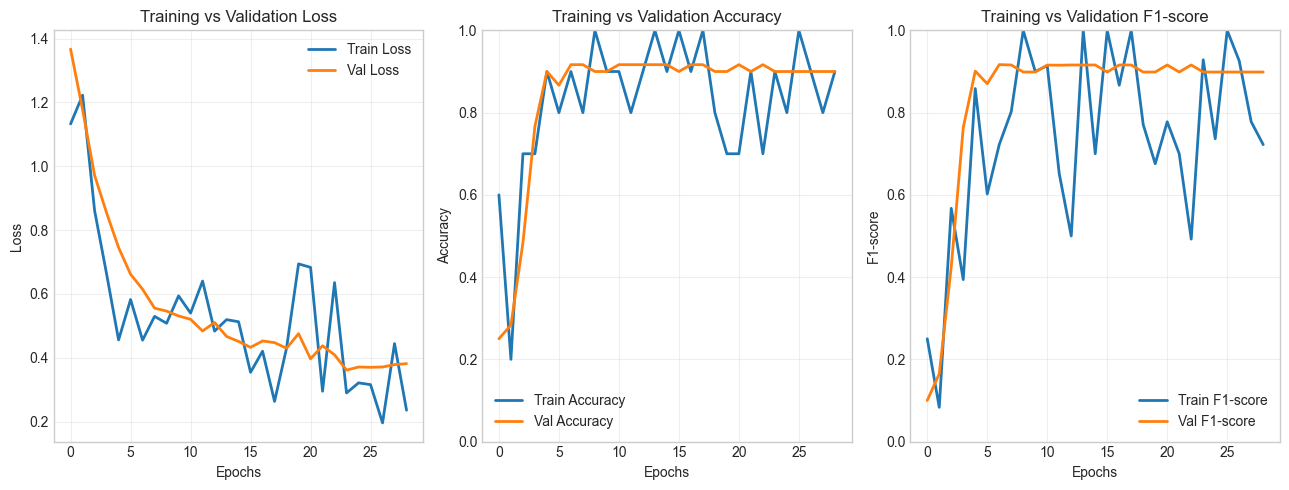

In [143]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(1, 3, figsize=(13, 5))

# -------- LOSS --------
ax[0].plot(tr_loss, label='Train Loss', linewidth=2)
ax[0].plot(val_loss, label='Val Loss', linewidth=2)
ax[0].set_title('Training vs Validation Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# -------- ACCURACY --------
ax[1].plot(acc_tr, label='Train Accuracy', linewidth=2)
ax[1].plot(acc_val, label='Val Accuracy', linewidth=2)
ax[1].set_title('Training vs Validation Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim(0, 1)
ax[1].legend()
ax[1].grid(True, alpha=0.3)

# -------- F1 SCORE --------
ax[2].plot(f1_tr, label='Train F1-score', linewidth=2)
ax[2].plot(f1_val, label='Val F1-score', linewidth=2)
ax[2].set_title('Training vs Validation F1-score')
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('F1-score')
ax[2].set_ylim(0, 1)
ax[2].legend()
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [144]:
def prediction_grid(x1, x2, final_W1, final_b1, final_W2, final_b2):
    y_grid = np.zeros((len(x2), len(x1)))
    for i in range(len(x1)):
        for j in range(len(x2)):
            y_grid[j, i] = np.argmax(forward_pass(np.array([[x1[i], x2[j]]]), final_W1, final_b1, final_W2, final_b2)[3], axis = 1)
            
    return y_grid
x1 = np.arange(np.min(X_val[:,0])-0.5, np.max(X_val[:,0])+0.5, 0.02)
x2 = np.arange(np.min(X_val[:,1])-0.5, np.max(X_val[:,1])+0.5, 0.02) 
y_grid = prediction_grid(x1, x2, final_W1, final_b1, final_W2, final_b2)

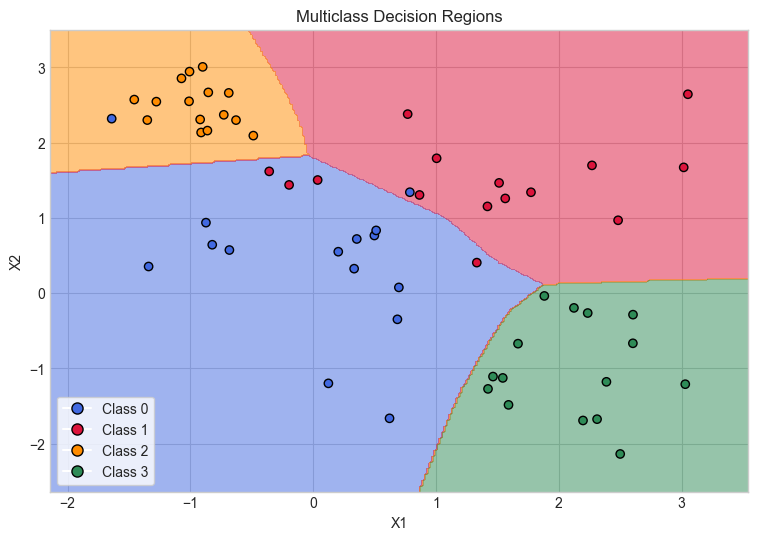

In [145]:
from matplotlib.lines import Line2D

cmap = ListedColormap([
    'royalblue',
    'crimson',
    'darkorange',
    'seagreen'
])

plt.figure(figsize=(9,6))

plt.contourf(
    x1,
    x2,
    y_grid,
    levels=np.arange(5)-0.5,
    cmap=cmap,
    alpha=0.5
)

plt.scatter(
    X_val[:,0],
    X_val[:,1],
    c=Y_val.ravel(),
    cmap=cmap,
    edgecolors='black'
)

# ---- legend ----
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Class 0',
        markerfacecolor='royalblue',
        markeredgecolor='black',
        markersize=8
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Class 1',
        markerfacecolor='crimson',
        markeredgecolor='black',
        markersize=8
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Class 2',
        markerfacecolor='darkorange',
        markeredgecolor='black',
        markersize=8
    ),

    
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Class 3',
        markerfacecolor='seagreen',
        markeredgecolor='black',
        markersize=8
    )
]

plt.legend(frameon = True, handles=legend_elements)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Multiclass Decision Regions')

plt.show()